# 18 - RQ4_A: BTC LLM ensemble weights and memory

## Methodology

DeepSeek assigns weekly weights to nine forecasting models. RealMemory uses
four completed seven-day outcome cards; NoMemory receives empty history;
ShuffledMemory permutes model identities. All three share current market
information. Hedge is the adaptive control; fixed LSTM is an additional reference.

The four adaptive variants use DZ65 probabilities, confidence 0.55, next-M15-open
entry, TP150/SL100, one-bar holding and 5 bp per side. Qualified Union handles
failed LLM answers. LSTM retains DZ55, confidence 0.75 and TP200/SL100.

All four variants run in **2024**, **January–June 2025** and **July 2025–March 2026**.
H1 selects the trading rule and Hedge learning rate. The 2024 replay is diagnostic;
the last period is the principal exploratory comparison on previously examined data.
Q2-2026 rows are excluded.

In [1]:
# Load notebook18 from the project or Google Drive.
import sys, hashlib, importlib.util
from pathlib import Path
from tempfile import gettempdir
from urllib.request import urlopen

if "google.colab" in sys.modules:
    publication = {'loader_id': '1Yr6wAAHTxg8GPlMZB-sS6PK6_08w5Vbp', 'loader_sha256': '093c578a0a4495f9b6a115afe98bb64e2ecde3c08373b0757a27772fdd330c1b', 'manifest_id': '1HpXJNRdj8orqNERXY5WoOD0wk8VA7uNf', 'manifest_sha256': 'd44af6ad5969c728dcceb5186c2af40f76b65fd341a3d9cd3f1cfa251f61d72f'}
    if not publication.get("manifest_id"):
        raise FileNotFoundError("The published RQ4 input manifest is required for Colab.")
    helper = Path(gettempdir()) / "colab_rq4_inputs.py"
    if not helper.is_file() or hashlib.sha256(helper.read_bytes()).hexdigest() != publication["loader_sha256"]:
        helper.write_bytes(urlopen("https://drive.usercontent.google.com/download?export=download&confirm=t&id=" + publication["loader_id"], timeout=60).read())
    assert hashlib.sha256(helper.read_bytes()).hexdigest() == publication["loader_sha256"]
    spec = importlib.util.spec_from_file_location("colab_rq4_inputs", helper)
    loader = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(loader)
    CODE = CODE_ROOT = loader.prepare(
        "https://drive.usercontent.google.com/download?export=download&confirm=t&id=" + publication["manifest_id"], publication["manifest_sha256"])
else:
    candidates = (Path.cwd(), *Path.cwd().parents)
    CODE = CODE_ROOT = next((p if (p / "pyproject.toml").is_file() else p / "code")
                            for p in candidates if (p / "pyproject.toml").is_file() or (p / "code/pyproject.toml").is_file())
    if str(CODE_ROOT) not in sys.path:
        sys.path.insert(0, str(CODE_ROOT))

Loading 120 RQ4 files from Google Drive...
Checked 25/120 files.
Checked 50/120 files.
Checked 75/120 files.
Checked 100/120 files.
RQ4 data ready.


In [2]:
import json
from html import escape
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display
from experiments.rq4_ensemble_reader import verify_reader

CACHE = CODE_ROOT / "experiments/cache/reflection_ensemble_v5"
audit = verify_reader(CACHE)
protocol = json.loads((CACHE / "protocol.json").read_text(encoding="utf-8"))
data_manifest = json.loads((CACHE / "data_manifest.json").read_text(encoding="utf-8"))
summary = pd.read_parquet(CACHE / "summary.parquet")
decisions = pd.read_parquet(CACHE / "weight_decisions.parquet")
comparisons = pd.read_parquet(CACHE / "paired_comparisons.parquet")
order = ["RealMemory", "NoMemory", "ShuffledMemory", "Hedge", "LSTM_fixed"]
labels = {"RealMemory": "Real memory", "NoMemory": "No memory", "ShuffledMemory": "Shuffled memory", "Hedge": "Hedge", "LSTM_fixed": "Fixed LSTM"}
model_labels = ["Logistic regression", "Decision tree", "Random forest", "Linear SVM", "XGBoost", "CatBoost", "MLP", "LSTM", "GRU"]
print(f"Verified {audit['models']} models, {audit['logical_llm_decisions']} LLM decisions and {audit['replayed_stage_arms']} stage/strategy replays.")
print(f"Memory, timing, accounting and all three paired intervals reproduced; {audit['fallback_weeks']} fallback weeks.")

Verified 9 models, 357 LLM decisions and 15 stage/strategy replays.
Memory, timing, accounting and all three paired intervals reproduced; 7 fallback weeks.


## Forecast coverage

The table counts eligible M15 forecasts and weekly blocks. Forecasts use a
prior-180-day fit for 2024, monthly H1 fits and frozen later predictions.

In [3]:
coverage = []
for stage, interval in sorted(protocol["stages"].items(), key=lambda item: pd.Timestamp(item[1][0])):
    frame = pd.concat([pd.read_parquet(CACHE / p, columns=["timestamp"]) for p in data_manifest["predictions"][stage]["logreg:w65"]])
    coverage.append({"Period": stage, "First forecast (UTC)": frame.timestamp.min(),
                     "Last forecast (UTC)": frame.timestamp.max(), "Rows per model": len(frame),
                     "Weekly blocks": audit["stage_weeks"][stage]})
display(pd.DataFrame(coverage))
display(Markdown(f"**Result:** the principal period contains **{coverage[-1]['Rows per model']:,} forecasts per model** across **{coverage[-1]['Weekly blocks']} weeks**. H1 selected Hedge's learning rate **eta = {protocol['hedge_eta']:g}**."))

,Period,First forecast (UTC),Last forecast (UTC),Rows per model,Weekly blocks
0,development,2024-01-01 00:00:00+00:00,2024-12-31 23:30:00+00:00,35135,53
1,h1,2025-01-01 00:00:00+00:00,2025-06-30 23:45:00+00:00,17376,26
2,forward,2025-07-01 00:00:00+00:00,2026-03-31 23:30:00+00:00,26303,40


**Result:** the principal period contains **26,303 forecasts per model** across **40 weeks**. H1 selected Hedge's learning rate **eta = 1**.

## Principal comparison: July 2025–March 2026

Net return and drawdown are additive percentages after costs, without compounding.
The four adaptive variants share execution settings; fixed LSTM retains its selected policy.

In [4]:
primary = summary.loc[summary.stage.eq("forward")].set_index("arm").loc[order]
display(pd.DataFrame({
    "Strategy": [labels[a] for a in order], "Net %": (primary.net_return * 100).round(2).to_numpy(),
    "Sortino": primary.sortino.round(2).to_numpy(), "Sharpe": primary.sharpe.round(2).to_numpy(),
    "Drawdown %": (primary.max_drawdown * 100).round(2).to_numpy(),
    "Trades": primary.trades.astype(int).to_numpy(), "Long": primary.n_long.astype(int).to_numpy(),
    "Short": primary.n_short.astype(int).to_numpy(), "Fallback weeks": primary.fallback_weeks.astype(int).to_numpy(),
}))
real = primary.loc["RealMemory"]
display(Markdown(f"**Result:** real memory returns **{100 * real.net_return:+.2f}%** from **{int(real.trades)} trades**, **{100 * (primary.loc['Hedge', 'net_return'] - real.net_return):.2f} percentage points** below Hedge."))

,Strategy,Net %,Sortino,Sharpe,Drawdown %,Trades,Long,Short,Fallback weeks
0,Real memory,-28.80,-4.81,-3.84,28.81,247,180,67,0
1,No memory,-73.73,-9.65,-7.96,74.61,510,262,248,1
2,Shuffled memory,-76.19,-9.47,-7.70,76.20,608,263,345,1
3,Hedge,-0.79,-0.39,-0.28,2.00,15,14,1,0
4,Fixed LSTM,3.58,1.57,0.86,2.78,54,16,38,0


**Result:** real memory returns **-28.80%** from **247 trades**, **28.01 percentage points** below Hedge.

## Memory contrasts and uncertainty

Paired four-week circular block bootstrap: 10,000 samples, seed 42.
Family-adjusted intervals cover three comparisons; differences are percentage points.

In [5]:
contrast_rows = []
for row in comparisons.itertuples():
    contrast_rows.append({"Contrast": row.contrast, "Difference (pp)": round(100 * row.net_difference, 2),
                          "95% interval (pp)": f"[{100 * row.ci95_low:+.2f}, {100 * row.ci95_high:+.2f}]",
                          "Family-adjusted interval (pp)": f"[{100 * row.familywise95_low:+.2f}, {100 * row.familywise95_high:+.2f}]"})
display(pd.DataFrame(contrast_rows))
lower = comparisons.set_index("contrast").familywise95_low
memory_supported = all(lower.loc["RealMemory - " + arm] > 0 for arm in ("NoMemory", "ShuffledMemory"))
hedge_supported = lower.loc["RealMemory - Hedge"] > 0
memory_text = "support a memory benefit against both LLM controls" if memory_supported else "do not establish a memory benefit against both LLM controls"
hedge_text = "also favour real memory over Hedge" if hedge_supported else "do not establish an advantage over Hedge"
display(Markdown(f"**Result:** adjusted intervals **{memory_text}** and **{hedge_text}**."))

,Contrast,Difference (pp),95% interval (pp),Family-adjusted interval (pp)
0,RealMemory - NoMemory,44.93,"[+5.31, +87.15]","[-2.75, +96.93]"
1,RealMemory - ShuffledMemory,47.38,"[+5.94, +85.01]","[-3.84, +92.64]"
2,RealMemory - Hedge,-28.01,"[-82.70, +0.65]","[-107.71, +1.30]"


**Result:** adjusted intervals **do not establish a memory benefit against both LLM controls** and **do not establish an advantage over Hedge**.

## Average model weights

Bars average weekly weights in July 2025–March 2026, excluding fallback weeks.

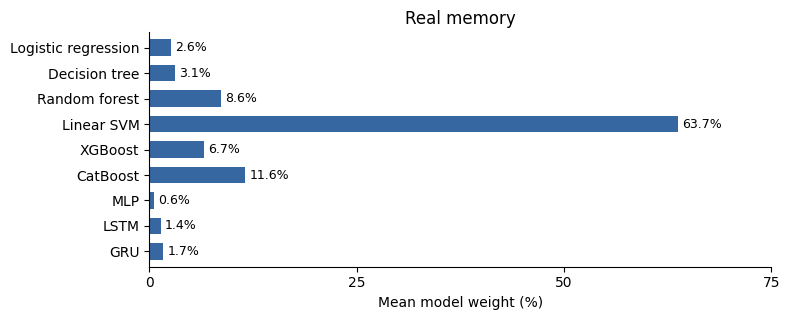

In [6]:
FIGURES = CACHE / "figures"
FIGURES.mkdir(exist_ok=True)
colours = ["#3767a0", "#78838d", "#c58b35", "#31877b", "#8265a5"]
weight_columns = ["w_" + name for name in protocol["model_names"]]
mean_weights = (decisions.loc[decisions.stage.eq("forward") & ~decisions.fallback]
                .groupby("arm")[weight_columns].mean().loc[order[:4]] * 100)
def plot_model_weights(arm):
    fig, ax = plt.subplots(figsize=(8, 3.3))
    bars = ax.barh(np.arange(9), mean_weights.loc[arm], color=colours[order.index(arm)], height=.65)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
    ax.set_yticks(range(9), model_labels)
    ax.set(title=labels[arm], xlabel="Mean model weight (%)", xlim=(0, 75), ylim=(8.6, -.6))
    ax.set_xticks([0, 25, 50, 75])
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(FIGURES / f"rq4_mean_weights_{arm}.png", dpi=180, bbox_inches="tight")
    plt.show()

plot_model_weights("RealMemory")

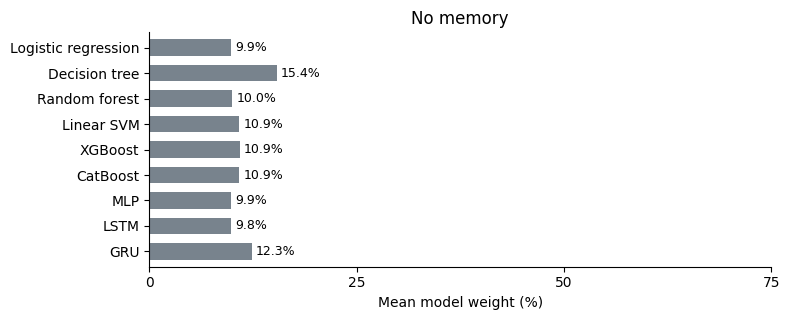

In [7]:
plot_model_weights("NoMemory")

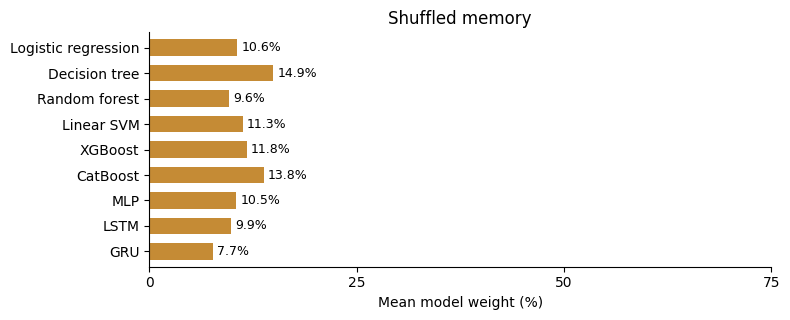

In [8]:
plot_model_weights("ShuffledMemory")

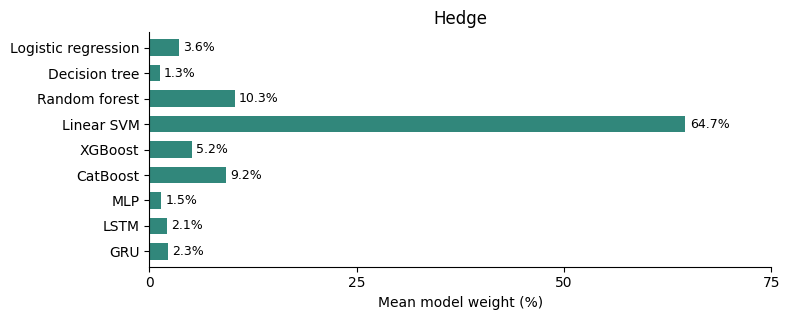

**Result:** real memory and Hedge favour Linear SVM (**63.7%** and **64.7%**); the two LLM controls spread weights more evenly.

In [9]:
plot_model_weights("Hedge")
display(Markdown(f"**Result:** real memory and Hedge favour Linear SVM (**{mean_weights.loc['RealMemory', 'w_svm_linear']:.1f}%** and **{mean_weights.loc['Hedge', 'w_svm_linear']:.1f}%**); the two LLM controls spread weights more evenly."))

## Net return by strategy

Bars show the same cost-adjusted totals as the principal comparison table.

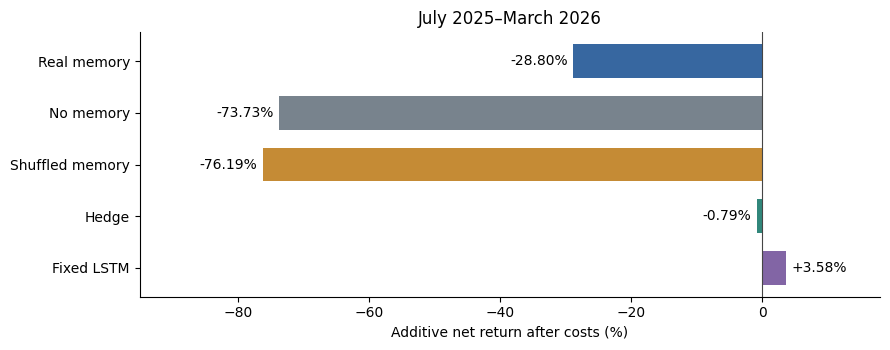

**Result:** fixed LSTM is the only positive strategy; all four adaptive variants lose after costs.

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.barh([labels[arm] for arm in order], primary.net_return * 100, color=colours, height=.65)
ax.bar_label(bars, fmt="%+.2f%%", padding=4, fontsize=10)
ax.invert_yaxis()
ax.axvline(0, color="#454545", linewidth=.8)
ax.set(xlabel="Additive net return after costs (%)", xlim=(-95, 18), title="July 2025–March 2026")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "rq4_net_return_bar.png", dpi=180, bbox_inches="tight")
plt.show()
display(Markdown("**Result:** fixed LSTM is the only positive strategy; all four adaptive variants lose after costs."))

## Development and calibration

2024 and H1 results use the H1-selected trading rule. These periods are
descriptive and do not provide independent validation.

In [11]:
secondary_rows = []
for stage in ("development", "h1"):
    frame = summary.loc[summary.stage.eq(stage)].set_index("arm").loc[order]
    for arm, row in frame.iterrows():
        secondary_rows.append({"Period": "2024 diagnostic" if stage == "development" else "H1-2025 calibration",
                               "Strategy": labels[arm], "Net %": round(100 * row.net_return, 2),
                               "Sortino": round(row.sortino, 2), "Drawdown %": round(100 * row.max_drawdown, 2),
                               "Trades": int(row.trades), "Fallback weeks": int(row.fallback_weeks)})
display(pd.DataFrame(secondary_rows))
hedge_secondary = summary.loc[summary.arm.eq("Hedge")].set_index("stage")
display(Markdown(f"**Result:** real memory loses in both periods. Hedge returns **{100 * hedge_secondary.loc['development', 'net_return']:+.2f}%** in 2024 and **{100 * hedge_secondary.loc['h1', 'net_return']:+.2f}%** in H1."))

,Period,Strategy,Net %,Sortino,Drawdown %,Trades,Fallback weeks
0,2024 diagnostic,Real memory,-11.36,-2.16,17.64,191,0
1,2024 diagnostic,No memory,-187.33,-12.41,190.31,2183,0
2,2024 diagnostic,Shuffled memory,-132.69,-11.19,135.88,1399,3
3,2024 diagnostic,Hedge,4.27,2.89,1.78,43,0
4,2024 diagnostic,Fixed LSTM,-89.52,-7.82,90.18,1069,0
5,H1-2025 calibration,Real memory,-19.55,-5.13,22.47,150,1
6,H1-2025 calibration,No memory,-47.84,-8.54,49.67,471,0
7,H1-2025 calibration,Shuffled memory,-57.40,-10.33,57.74,475,1
8,H1-2025 calibration,Hedge,3.20,2.34,2.64,25,0
9,H1-2025 calibration,Fixed LSTM,2.56,1.15,4.71,79,0


**Result:** real memory loses in both periods. Hedge returns **+4.27%** in 2024 and **+3.20%** in H1.

## Reproducibility

Saved forecasts and LLM replies are independently checked against every reported result.

In [12]:
display(pd.DataFrame([
    {"Check": "Forecast models / reconstructed stage-strategies", "Result": f"{audit['models']} / {audit['replayed_stage_arms']}"},
    {"Check": "LLM decisions / unique recorded calls", "Result": f"{audit['logical_llm_decisions']} / {audit['unique_llm_calls']}"},
    {"Check": "Memory and current-state audits", "Result": str(audit["memory_and_current_state_audits"])},
    {"Check": "Failed-decision fallback weeks", "Result": str(audit["fallback_weeks"])},
    {"Check": "Replies revalidated at the decimal sum boundary", "Result": str(audit["decimal_boundary_revalidations"])},
    {"Check": "Old forward LSTM reproduced", "Result": str(audit["old_forward_lstm_exact"])},
    {"Check": "Q2 rows read", "Result": str(audit["q2_rows_read"])},
]))
display(Markdown(f"**Result:** all checks pass; **{audit['logical_llm_decisions']} decisions** are reconstructed, with **{audit['fallback_weeks']} fallback weeks** across all periods."))
calls = pd.read_parquet(CACHE / "llm_call_audit.parquet")
record = json.loads(calls.iloc[0].record_json)
details = "<details><summary>Exact prompt, model settings and fresh-run commands</summary>"
details += "<pre>" + escape(record["request"]["messages"][0]["content"]) + "</pre>"
details += "<pre>" + escape(json.dumps(protocol["transport"], indent=2)) + "</pre>"
details += "<p>Model digest: <code>" + escape(protocol["model_digest"]) + "</code></p>"
details += "<p>The versioned project code includes the forecast producer and cloud runner. A fresh cloud run requires access to the same Ollama model.</p>"
details += "<pre>python -m experiments.rq4_nine_model_data\npython -m experiments.run_reflection_ensemble\npython -m experiments.rq4_ensemble_reader --seal</pre></details>"
display(HTML(details))

,Check,Result
0,Forecast models / reconstructed stage-strategies,9 / 15
1,LLM decisions / unique recorded calls,357 / 355
2,Memory and current-state audits,357
3,Failed-decision fallback weeks,7
4,Replies revalidated at the decimal sum boundary,4
5,Old forward LSTM reproduced,True
6,Q2 rows read,0


**Result:** all checks pass; **357 decisions** are reconstructed, with **7 fallback weeks** across all periods.

## Results

Real memory returns **−28.80%** from 247 trades, compared with −73.73% without
memory and −76.19% with shuffled memory. Hedge returns −0.79%; fixed LSTM +3.58%.
All three adjusted intervals include zero.

Takeaway: Real memory reduces observed losses against the LLM controls, but
does not establish a profitable strategy or an advantage over Hedge.